# Draws admissible regions and SNR maps
Run `convert_hdf5_data` before running this file.

## Specify rotation and folder names

In [10]:
# For folder names and simulation file structure refer to </README.md>
m_mark = "[1,j]"  # rotation; By default it's [1,+j]
folder_name = r"F:\Contents\2024-08-20 Array noise"  # The folder where all CST simulation files are located
save_picture_folder_name = r"F:\Contents\2024-08-20 Array noise"  # The folder to save pictures to

## Run

In [ ]:
import itertools
import matplotlib
from matplotlib import colors
from matplotlib import pyplot as plt
from matplotlib import ticker
import numpy as np
from rx_array_snr_evaluation import field
from importlib import reload
reload(field)


def mask_ROI(position: np.ndarray, h_field: np.ndarray) -> np.ndarray: 
    """ Defines region of interest
        Now it's a circle centered at (0, 0), radius 100.
    """
    return np.linalg.norm(position[:, 0:2], axis=1) <= 100.

# There are nine simulation files
# Generates all folder names containing simulation results
# 12ch, outer_radius=134.00, loop_xy=97.60
# 12ch, outer_radius=171.28, loop_xy=120.57
# 12ch, outer_radius=208.56, loop_xy=143.93
#16ch, outer_radius=134.00, loop_xy=73.73
# 16ch, outer_radius=171.28, loop_xy=91.43
# 16ch, outer_radius=208.56, loop_xy=109.02
# 8ch, outer_radius=134.00, loop_xy=146.11
# 8ch, outer_radius=171.28, loop_xy=181.24
# 8ch, outer_radius=208.56, loop_xy=213.48


ch_n = np.array([8, 12, 16], dtype=np.int_)
sizes = np.array([134.00, 171.28, 208.56], dtype=np.float_)
loop_xys = np.array([[146.11, 181.24, 213.48], 
                     [97.60, 120.57, 143.93], 
                     [73.73, 91.43, 109.02]])
subfolder_names = [[], [], []]
for iter_m, iter_n in itertools.product([0, 1, 2], [0, 1, 2]):
    subfolder_name = f"{folder_name:s}\\{ch_n[iter_m]:d}ch, outer_radius={sizes[iter_n]:.2f}, loop_xy={loop_xys[iter_m, iter_n]:.2f}"
    subfolder_names[iter_m].append(subfolder_name)

# Transistors: Noiseless, Elcry2-u (elcry.com), Infineon BFP740, Infineon BFR35AP
# Transistor noise parameters: F_{opt}—minimum noise figure (linear scale), Z_{opt}—optimal noise impedance, R_{no}—noise resistance, just a parameter
# Some transistor parameters are not listed in datasheets; they are extracted from ADS simulation. Just accept them as they are. 
# BFP740 3 V, 6 mA; BFR35AP 10 V, 10 mA
transistor_names = ["Noiseless", "Elcry2-u", "BFP740", "BFR35AP"]
f_opt = 10 ** (np.array([0, 0.406208, 0.43869, 1.11818]) / 10)  
z_opt = np.array([50, 57.306557 + 21.569136j, 123.67115 + 3.12944j, 62.49675 + 2.55972j])
r_no = np.array([0, 1.926394, 6.15520, 8.01097], dtype=np.float_)
g_noise = (r_no / np.abs(z_opt) ** 2).astype(np.float_)  # Rn / z_opt ** 2, equivalent to matrix [D]
lange_N = np.real(z_opt) * g_noise


In [3]:
# Show lange_N, just to be sure
lange_N

array([0.        , 0.02944441, 0.04973885, 0.12796752])

## Load Data
I assume you have already run `convert_hdf5_data` before running this file.
For folder names and simulation file structure refer to </README.md>

In [4]:
snr_mappers = np.empty((3, 3, len(transistor_names)), dtype=np.object_)
z_matrix_generators = np.empty((3, 3, len(transistor_names)), dtype=np.object_)
for iter_m, iter_n, iter_o in itertools.product([0, 1, 2], [0, 1, 2], range(len(transistor_names))):
    z_matrix_generator_file_name = f"{subfolder_names[iter_m][iter_n]}\\z_matrix_generator_data-{transistor_names[iter_o]}-{m_mark}"
    snr_mapper_file_name = f"{subfolder_names[iter_m][iter_n]}\\snr_mapper_data-{transistor_names[iter_o]}-{m_mark}"
    print(f"Loading {z_matrix_generator_file_name}")
    print(f"Loading {snr_mapper_file_name}")
    z_matrix_generators[iter_m, iter_n, iter_o] = field.ImpedanceMatrixGenerator.load(z_matrix_generator_file_name)
    snr_mappers[iter_m, iter_n, iter_o] = field.SNRMapper.load(snr_mapper_file_name)



Loading F:\Contents\2024-08-20 Array noise\8ch, outer_radius=134.00, loop_xy=146.11\z_matrix_generator_data-Noiseless-[1,j]
Loading F:\Contents\2024-08-20 Array noise\8ch, outer_radius=134.00, loop_xy=146.11\snr_mapper_data-Noiseless-[1,j]
Loading F:\Contents\2024-08-20 Array noise\8ch, outer_radius=134.00, loop_xy=146.11\z_matrix_generator_data-Elcry2-u-[1,j]
Loading F:\Contents\2024-08-20 Array noise\8ch, outer_radius=134.00, loop_xy=146.11\snr_mapper_data-Elcry2-u-[1,j]
Loading F:\Contents\2024-08-20 Array noise\8ch, outer_radius=134.00, loop_xy=146.11\z_matrix_generator_data-BFP740-[1,j]
Loading F:\Contents\2024-08-20 Array noise\8ch, outer_radius=134.00, loop_xy=146.11\snr_mapper_data-BFP740-[1,j]
Loading F:\Contents\2024-08-20 Array noise\8ch, outer_radius=134.00, loop_xy=146.11\z_matrix_generator_data-BFR35AP-[1,j]
Loading F:\Contents\2024-08-20 Array noise\8ch, outer_radius=134.00, loop_xy=146.11\snr_mapper_data-BFR35AP-[1,j]
Loading F:\Contents\2024-08-20 Array noise\8ch, oute

In [5]:
# Reduce memory usage
# Extracts one `point_coordinates` and copy them to all `SNRMapper` instances in `snr_mappers`. 
array_pos_roi0 = snr_mappers[0, 0, 0].point_coordinates  # point coordinates are the same for all setups
center_location_all, _ = field.SNRMapper.find_nearest_point(array_pos_roi0, np.array([0, 0, 115]))
for iter_m, iter_n, iter_o in itertools.product([0, 1, 2], [0, 1, 2], range(len(transistor_names))):
    snr_mappers[iter_m, iter_n, iter_o]._point_coordinates = snr_mappers[0, 0, 0]._point_coordinates  # This copies the pointer instead of the whole memory block. The original coordinates of each class instance will be recycled by garbage collector.

## Draw Admissible Regions
Admissible regions are not related to preamplifiers. This is why I use noiseless transistors for computing them.

In [6]:
transistor_n = 0  # Noiseless
admissible_region_plots = np.empty((3, 3), dtype=np.object_)
for iter_m, iter_n in itertools.product([0, 1, 2], [0, 1, 2]):
    admissible_mask = z_matrix_generators[iter_m, iter_n, transistor_n]._last_signal_vectors_admissible_mask.copy()  # Make a memory copy instead of pointer copy
    print(np.sum(admissible_mask))
    admissible_transparent = np.full(admissible_mask.shape, 0, np.int_)
    admissible_transparent[admissible_mask] = 1
    admissible_region_plots[iter_m, iter_n] = snr_mappers[iter_m, iter_n, transistor_n].put_map_on_regular_grid(admissible_transparent)[..., 0]  # Need to use SNRMapper instances to draw
    print(admissible_region_plots[iter_m, iter_n].shape)

78620
(1001, 1001)
40117
(1001, 1001)
8750
(1001, 1001)
15970
(1001, 1001)
2592
(1001, 1001)
0
(1001, 1001)
8193
(1001, 1001)
311
(1001, 1001)
0
(1001, 1001)


In [7]:
admissible_region_plots[0, 0].shape

(1001, 1001)

In [8]:
# Circles that marks the region of interest
circle_phi = np.linspace(0, 2 * np.pi, 5001, False)
circle_x = admissible_region_plots[0, 0].shape[0] * (np.cos(circle_phi) + 1) / 2 +1
circle_y = admissible_region_plots[0, 0].shape[0] * (np.sin(circle_phi) + 1) / 2 - 1


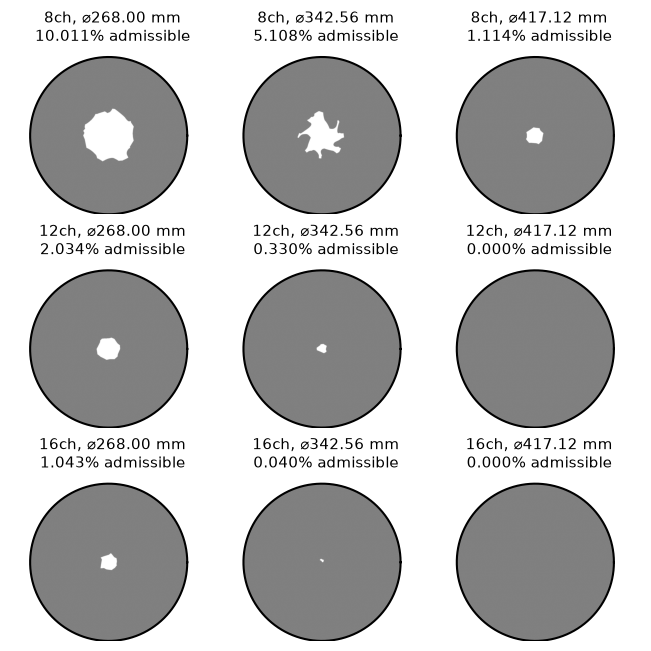

In [11]:
# Plot admissible regions, generate F3-[1,j].png
fig, axs = plt.subplots(3, 3, layout="constrained")
fig.set_size_inches((6.4, 6.4))

contour_handles = []
circle_handles = []
for iter_m, iter_n in itertools.product([0, 1, 2], [0, 1, 2]):
    # contour_handles.append(axs[iter_n].contourf(snr_prdcpl_plots[iter_n], vmin=.75, levels=scop_levels))
    contour_handles.append(axs[iter_m, iter_n].imshow(admissible_region_plots[iter_m, iter_n], vmin=-1.0, vmax=1.0, cmap="gray"))
    circle_handles.append(axs[iter_m, iter_n].plot(circle_x, circle_y, color="black"))
    # plt.show()
    admissible_proportion = np.sum(z_matrix_generators[iter_m, iter_n, transistor_n]._last_signal_vectors_admissible_mask) \
        / np.size(z_matrix_generators[iter_m, iter_n, transistor_n]._last_signal_vectors_admissible_mask)
    axs[iter_m, iter_n].axis("equal")
    axs[iter_m, iter_n].set_axis_off()
    axs[iter_m, iter_n].set_title(f"{ch_n[iter_m]}ch, ⌀{sizes[iter_n] * 2:.2f} mm\n{admissible_proportion:.3%} admissible", fontsize=11)

plt.savefig(save_picture_folder_name + f"\\F3-{m_mark}.png", dpi=300)

## Analyze SNR improvements
Generates pictures F4(a), F4(b), F4(c); F5(a), F5(b), F5(c). Then the pictures will be patched together by Inkscape or GIMP.

In [12]:
snr_improvements = np.empty((3, 3, len(transistor_names)), dtype=np.object_)
for itm, itn, ito in itertools.product([0, 1, 2], [0, 1, 2], range(len(transistor_names))):
    if snr_mappers[itm, itn, ito]._SNR_map_bundle is not None:
        if ito == 0:
            print(f"z_diag_elements:\n{z_matrix_generators[itm, itn, ito]._last_diag_Z_elements[center_location_all, ...]}")
            print(f"Za's diagonals:\n{np.diag(z_matrix_generators[itm, itn, ito]._Za)}")
        current_snr_improvement = snr_mappers[itm, itn, ito]._SNR_map_bundle / snr_mappers[itm, itn, ito]._ref_SNR_map - 1
        print(f"{ch_n[itm]:d}ch, size{itn+1:d}, {transistor_names[ito]}: min={current_snr_improvement.min():.5%}, max={current_snr_improvement.max():.5%}, "
            f"center={current_snr_improvement[center_location_all]:.5%}, mean={np.mean(current_snr_improvement):.5%}, $\\sigma$={np.std(current_snr_improvement):.5f}")
        snr_improvements[itm, itn, ito] = current_snr_improvement
    # print(snr_mappers[itm, itn, ito]._SNR_map_bundle)

z_diag_elements:
[11.68919428+49.98534319j 13.09399166+50.2512906j
 11.4968403 +49.57369689j 13.85839877+50.10460102j
 11.70732618+50.37958268j 12.88550967+49.72099771j
 12.01094354+49.61192848j 13.3026093 +50.24742067j]
Za's diagonals:
[5.43296087+47.67952669j 5.96233086+47.50133392j 5.43577114+47.69628779j
 5.964826  +47.51941j    5.44997303+47.66647943j 5.96322469+47.47173062j
 5.42905474+47.57285864j 5.96334064+47.50130223j]
8ch, size1, Noiseless: min=0.00000%, max=0.00000%, center=0.00000%, mean=0.00000%, $\sigma$=0.00000
8ch, size1, Elcry2-u: min=-5.64094%, max=2.66062%, center=1.95559%, mean=-1.74123%, $\sigma$=0.02452
8ch, size1, BFP740: min=-8.17618%, max=4.33138%, center=3.27862%, mean=-2.35507%, $\sigma$=0.03699
8ch, size1, BFR35AP: min=-13.55755%, max=8.92872%, center=7.21266%, mean=-3.25128%, $\sigma$=0.06677
z_diag_elements:
[5.04794537+59.62414828j 5.58113978+58.59720101j 6.03997674+59.6893894j
 4.853208  +59.35962727j 5.61787397+58.23614197j 6.26646843+60.03615389j
 4.5

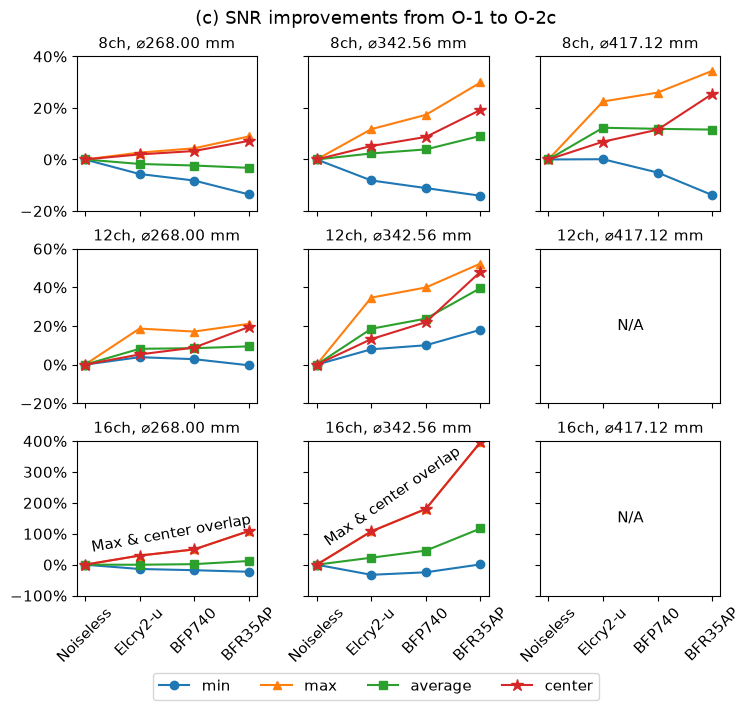

In [13]:
# Generates picture F4(c)

fig, axs = plt.subplots(3, 3, sharex="all", sharey="row", layout="constrained")
fig.suptitle("(c) SNR improvements from O-1 to O-2c", fontsize=13)
fig.set_size_inches((7.4, 7))
x_ticks = range(len(transistor_names))
for itm, itn in itertools.product(range(3), range(3)):
    if snr_improvements[itm, itn, 0] is not None:
        axs[itm, itn].plot(x_ticks, [np.min(snr_improvements[itm, itn, ito]) for ito in x_ticks], marker="o", label="min")
        axs[itm, itn].plot(x_ticks, [np.max(snr_improvements[itm, itn, ito]) for ito in x_ticks], marker="^", label="max")
        axs[itm, itn].plot(x_ticks, [np.mean(snr_improvements[itm, itn, ito]) for ito in x_ticks], marker="s", label="average")
        axs[itm, itn].plot(x_ticks, [snr_improvements[itm, itn, ito][center_location_all] for ito in x_ticks], marker="*", label="center", markersize=9)
    axs[itm, itn].set_title(f"{ch_n[itm]:d}ch, ⌀{sizes[itn] * 2:.2f} mm", fontsize=11) # , $\\sigma$={np.std(snr_improvements[itm, itn, ito]):.1%}
    axs[itm, itn].set_xticks(x_ticks, transistor_names, rotation=45, fontsize=11)
    axs[itm, itn].tick_params(axis="both", which="major", labelsize=11)
    axs[itm, itn].tick_params(axis="both", which="minor", labelsize=11)
    # axs[itm, itn].set_yscale("log")


axs[0, 0].set_ylim((-0.2, 0.4))
axs[1, 0].set_ylim((-0.2, 0.6))
axs[2, 0].set_ylim((-1, 4))
for itm, itn in itertools.product(range(3), range(3)):
    axs[itm, itn].yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1, decimals=0))
    axs[itm, itn].yaxis.set_minor_formatter(ticker.PercentFormatter(xmax=1, decimals=0))
axs[2, 0].annotate("Max & center overlap", xy=(0.1, 0.3), xycoords="data", verticalalignment="bottom", fontsize=11, rotation=10)
axs[2, 1].annotate("Max & center overlap", xy=(0.1, 0.5), xycoords="data", verticalalignment="bottom", fontsize=11, rotation=35)
axs[1, 2].text(0.5, 0.5, "N/A", horizontalalignment="center", verticalalignment="center", fontsize=11, transform=axs[1, 2].transAxes)
axs[2, 2].text(0.5, 0.5, "N/A", horizontalalignment="center", verticalalignment="center", fontsize=11, transform=axs[2, 2].transAxes)
handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="outside lower center", ncols=4, fontsize=11)

plt.savefig(save_picture_folder_name + f"\\F4c-{m_mark}.png", dpi=300)

In [14]:
# min_SNR_noiseless = snr_mappers[0, 0, 0]._ref_SNR_map.min()
# Preamp decoupling, anchor value = noiseless amplifier, center pixel
center_location_all, _ = field.SNRMapper.find_nearest_point(array_pos_roi0, np.array([0, 0, 115]))
print(f"{center_location_all=:d}")
snr_center_opts = np.empty((3, 3, len(transistor_names)), dtype=np.object_)
snr_center_noiseless_values = np.zeros((3, 3), dtype=np.float_)
for itm, itn, ito in itertools.product([0, 1, 2], [0, 1, 2], range(len(transistor_names))):
    if snr_mappers[itm, itn, ito]._ref_SNR_map is not None:
        if ito == 0:
            current_center_location, snr_center_noiseless_values[itm, itn] = snr_mappers[itm, itn, ito].SNR_ref_value( \
                np.array([0, 0, 115]), \
                ref=field.SNRMapper.RefSelect.FIRST_REFERENCE_CORE \
            )
            # print(f"{current_center_location=:d}")
        if snr_mappers[itm, itn, ito]._SNR_map_bundle is None:
            continue
        current_snr_ratio = snr_mappers[itm, itn, ito]._SNR_map_bundle / snr_center_noiseless_values[itm, itn]
        snr_center_opts[itm, itn, ito] = current_snr_ratio
        print(f"{ch_n[itm]:d}ch, size{itn+1:d}, {transistor_names[ito]}: min={current_snr_ratio.min():.5%}, max={current_snr_ratio.max():.5%}, "
            f"center={current_snr_ratio[center_location_all]:.5%}, mean={np.mean(current_snr_ratio):.5%}, $\\sigma$={np.std(current_snr_ratio):.5f}")

center_location_all=392672
8ch, size1, Noiseless: min=99.95893%, max=3611.41339%, center=100.00000%, mean=1099.30132%, $\sigma$=8.75739
8ch, size1, Elcry2-u: min=91.03126%, max=2589.23412%, center=91.07081%, mean=836.50855%, $\sigma$=6.32293
8ch, size1, BFP740: min=90.35131%, max=2303.84749%, center=90.39221%, mean=763.75396%, $\sigma$=5.63596
8ch, size1, BFR35AP: min=77.26195%, max=1589.52130%, center=77.30045%, mean=546.66282%, $\sigma$=3.83542
8ch, size2, Noiseless: min=99.96516%, max=2758.20144%, center=100.00000%, mean=932.77216%, $\sigma$=7.01997
8ch, size2, Elcry2-u: min=91.03426%, max=1466.55673%, center=91.07081%, mean=567.22782%, $\sigma$=3.71169
8ch, size2, BFP740: min=90.35316%, max=1242.62780%, center=90.39221%, mean=494.98968%, $\sigma$=3.10476
8ch, size2, BFR35AP: min=77.26032%, max=788.56223%, center=77.30045%, mean=332.05591%, $\sigma$=1.91345
8ch, size3, Noiseless: min=99.95254%, max=1750.54127%, center=100.00000%, mean=654.62042%, $\sigma$=4.38008
8ch, size3, Elcry2-

[-0.25  0.    1.25]


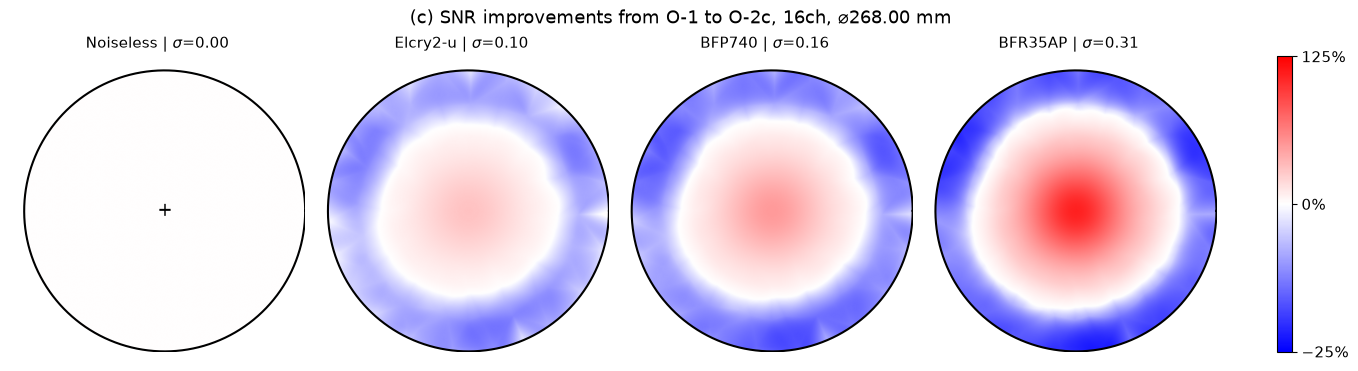

In [15]:
# Generates picture F5(c)

fig, axs = plt.subplots(1, len(transistor_names), sharey="row", layout="constrained")
fig.set_size_inches((13.5, 3.6))
snr_improvement_plots = np.empty(len(transistor_names), dtype=np.object_)
mappable_objects = np.empty(len(transistor_names), dtype=np.object_)
ch_select = 2  # 16 ch
size_select = 0  # radius 134 mm
fig.suptitle(f"(c) SNR improvements from O-1 to O-2c, {ch_n[ch_select]}ch, ⌀{sizes[size_select] * 2:.2f} mm", fontsize=13)
circle_phi = np.linspace(0, 2 * np.pi, 5001, False)
circle_x = admissible_region_plots[0, 0].shape[0] * (np.cos(circle_phi) + 1) / 2 - 1
circle_y = admissible_region_plots[0, 0].shape[0] * (np.sin(circle_phi) + 1) / 2 - 1
contour_colormap = matplotlib.colormaps["bwr"]
ctf_start, ctf_end, ctf_count = -0.25, 1.25, 16
ctf_levels=np.array([-0.25, 0., 1.25])
# ctf_levels = np.linspace(ctf_start, ctf_end, num=ctf_count, endpoint=True)
# fx = lambda x: 0.4 * x + 0.5
# contour_colors = contour_colormap(np.linspace(fx(ctf_start), fx(ctf_end), num=ctf_count, endpoint=True))
color_norm=colors.TwoSlopeNorm(0, -0.25, +1.25)
for ito in range(len(transistor_names)):
    snr_improvement_plots[ito] = snr_mappers[ch_select, size_select, ito].put_map_on_regular_grid(\
        snr_improvements[ch_select, size_select, ito], \
        )[..., 0]
    mappable_objects[ito] = axs[ito].imshow(snr_improvement_plots[ito], cmap="bwr", 
                                            norm=color_norm)
    axs[ito].plot(circle_x, circle_y, color="black")
    axs[ito].axis("equal")
    axs[ito].set_axis_off()
    axs[ito].set_title(f"{transistor_names[ito]} | $\\sigma$={np.std(snr_improvements[ch_select, size_select, ito]):.2f}", fontsize=11) # 

# def format(x, pos: np.number) -> str:
#     if pos % 2 != 0:
#         return ""
#     else:
#         return f"{x:.0%}"

axs[0].text(500.5, 500.5, "+", horizontalalignment="center", verticalalignment="center", fontsize=13)
# cbar = fig.colorbar(mappable_objects[0], ax=axs, ticks=ctf_levels, format=ticker.FuncFormatter(format))
cbar = fig.colorbar(mappable_objects[0], ax=axs, ticks=ctf_levels, format=ticker.StrMethodFormatter("{x:.0%}"))
cbar.ax.tick_params(labelsize=11)
print(ctf_levels)
plt.savefig(save_picture_folder_name+f"\\F5c-{m_mark}.png", dpi=300)

Analyzing SNR of preamp decoupling

Noiseless as references

In [16]:
color_norm(0)

0.5

In [17]:
# min_SNR_noiseless = snr_mappers[0, 0, 0]._ref_SNR_map.min()
# Preamp decoupling, anchor value = noiseless amplifier, center pixel
center_location_all, _ = field.SNRMapper.find_nearest_point(array_pos_roi0, np.array([0, 0, 115]))
print(f"{center_location_all=:d}")
snr_ratio_maps = np.empty((3, 3, len(transistor_names)), dtype=np.object_)
snr_center_noiseless_values = np.zeros((3, 3), dtype=np.float_)
for itm, itn, ito in itertools.product([0, 1, 2], [0, 1, 2], range(len(transistor_names))):
    if snr_mappers[itm, itn, ito]._ref_SNR_map is not None:
        if ito == 0:
            current_center_location, snr_center_noiseless_values[itm, itn] = snr_mappers[itm, itn, ito].SNR_ref_value( \
                np.array([0, 0, 115]), \
                ref=field.SNRMapper.RefSelect.FIRST_REFERENCE_CORE \
            )
            print(f"{current_center_location=:d}")
        current_snr_ratio = snr_mappers[itm, itn, ito]._ref_SNR_map / snr_center_noiseless_values[itm, itn]
        snr_ratio_maps[itm, itn, ito] = current_snr_ratio
        print(f"{ch_n[itm]:d}ch, size{itn+1:d}, {transistor_names[ito]}: min={current_snr_ratio.min():.5%}, max={current_snr_ratio.max():.5%}, "
            f"center={current_snr_ratio[center_location_all]:.5%}, mean={np.mean(current_snr_ratio):.5%}, $\\sigma$={np.std(current_snr_ratio):.5f}")

center_location_all=392672
current_center_location=392672
8ch, size1, Noiseless: min=99.95893%, max=3611.41339%, center=100.00000%, mean=1099.30132%, $\sigma$=8.75739
8ch, size1, Elcry2-u: min=89.28363%, max=2726.91917%, center=89.32400%, mean=866.17097%, $\sigma$=6.67025
8ch, size1, BFP740: min=87.48083%, max=2485.11215%, center=87.52267%, mean=802.76862%, $\sigma$=6.09871
8ch, size1, BFR35AP: min=72.06138%, max=1782.29978%, center=72.10011%, mean=592.07258%, $\sigma$=4.39519
current_center_location=392672
8ch, size2, Noiseless: min=99.96516%, max=2758.20144%, center=100.00000%, mean=932.77216%, $\sigma$=7.01997
8ch, size2, Elcry2-u: min=86.50994%, max=1563.32709%, center=86.55293%, mean=575.92274%, $\sigma$=4.00750
8ch, size2, BFP740: min=83.07433%, max=1355.23484%, center=83.12259%, mean=503.06465%, $\sigma$=3.46226
8ch, size2, BFR35AP: min=64.78224%, max=877.88773%, center=64.83348%, mean=330.03893%, $\sigma$=2.22054
current_center_location=392672
8ch, size3, Noiseless: min=99.9525

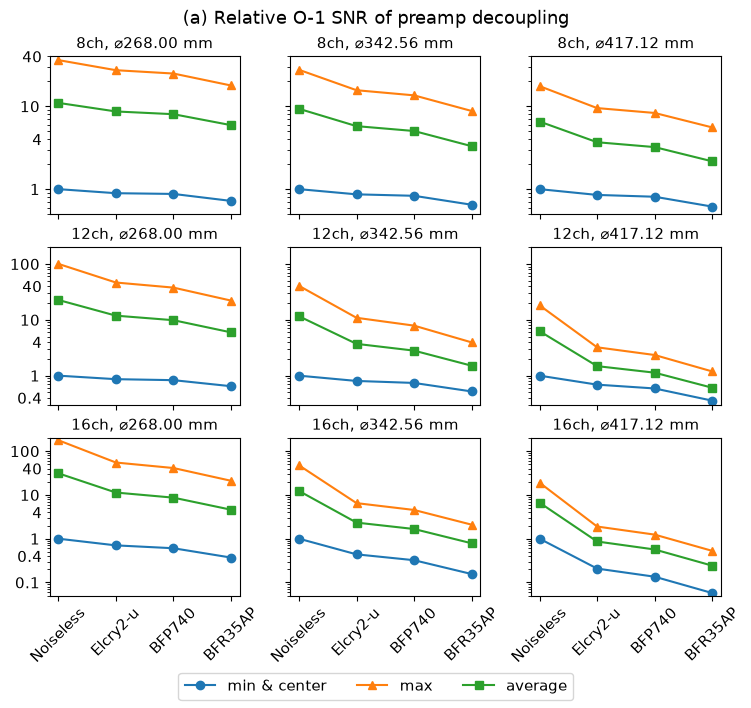

In [18]:
# Generates picture F4(a)

fig, axs = plt.subplots(3, 3, sharex="all", sharey="row", layout="constrained")
fig.suptitle("(a) Relative O-1 SNR of preamp decoupling", fontsize=13)
fig.set_size_inches((7.4, 7))
x_ticks = range(len(transistor_names))
for itm, itn in itertools.product(range(3), range(3)):
    axs[itm, itn].plot(x_ticks, [np.min(snr_ratio_maps[itm, itn, ito]) for ito in range(len(transistor_names))], marker="o", label="min & center")
    axs[itm, itn].plot(x_ticks, [np.max(snr_ratio_maps[itm, itn, ito]) for ito in range(len(transistor_names))], marker="^", label="max")
    axs[itm, itn].plot(x_ticks, [np.mean(snr_ratio_maps[itm, itn, ito]) for ito in range(len(transistor_names))], marker="s", label="average")
    axs[itm, itn].set_title(f"{ch_n[itm]:d}ch, ⌀{sizes[itn] * 2:.2f} mm", fontsize=11) # $\\sigma$={np.std(snr_ratio_maps[itm, itn, ito]):.1%}
    axs[itm, itn].set_xticks(x_ticks, transistor_names, rotation=45, fontsize=11)
    axs[itm, itn].tick_params(axis="both", which="major", labelsize=11)
    axs[itm, itn].tick_params(axis="both", which="minor", labelsize=11)
    axs[itm, itn].set_yscale("log")

def format(x: np.number, _) -> str:
    first_significant_digit = np.int_(np.floor(x / 10 ** np.floor(np.log10(x))))
    if first_significant_digit == 1 or first_significant_digit == 4:
        if x < 1:
            return f"{x:.1g}"
        else:
            return f"{int(np.floor(x)):d}"
    else:
        return ""

axs[0, 0].set_ylim((0.5, 40))
axs[1, 0].set_ylim((0.3, 200))
axs[2, 0].set_ylim((0.05, 200))
for itm, itn in itertools.product(range(3), range(3)):
    axs[itm, itn].yaxis.set_major_formatter(ticker.FuncFormatter(format))
    axs[itm, itn].yaxis.set_minor_formatter(ticker.FuncFormatter(format))

handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="outside lower center", ncols=3, fontsize=11)
plt.savefig(save_picture_folder_name+f"\\F4a-{m_mark}.png", dpi=300)

[  0.3679   1.     177.503 ]


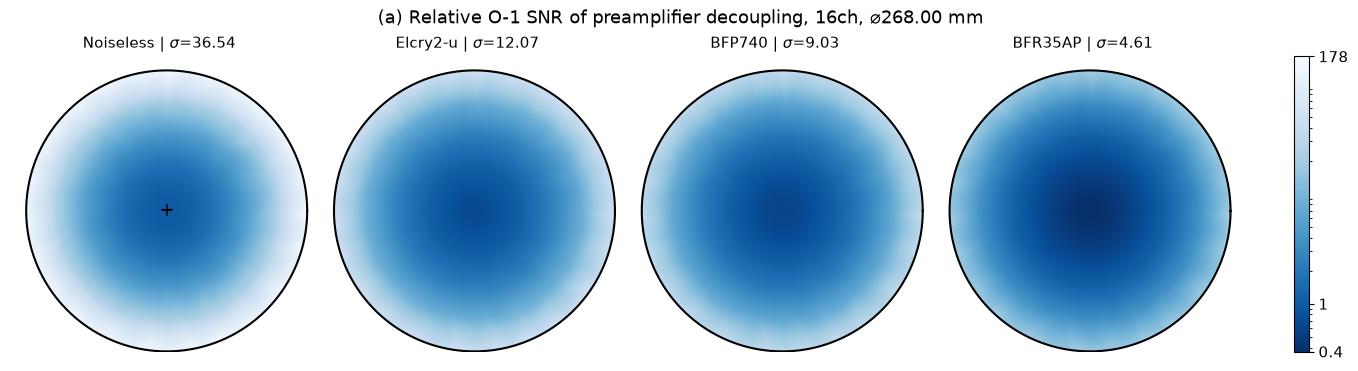

In [19]:
# Generates F5(a)

fig, axs = plt.subplots(1, len(transistor_names), sharey="row", layout="constrained")
fig.set_size_inches((13.5, 3.6))
snr_prdcpl_plots = np.empty(len(transistor_names), dtype=np.object_)
mappable_objects = np.empty(len(transistor_names), dtype=np.object_)
ch_select = 2  # 16 ch
size_select = 0  # radius 134 mm
fig.suptitle(f"(a) Relative O-1 SNR of preamplifier decoupling, {ch_n[ch_select]}ch, ⌀{sizes[size_select] * 2:.2f} mm", fontsize=13)
circle_phi = np.linspace(0, 2 * np.pi, 5001, False)
circle_x = admissible_region_plots[0][0].shape[0] * (np.cos(circle_phi) + 1) / 2 - 1
circle_y = admissible_region_plots[0][0].shape[0] * (np.sin(circle_phi) + 1) / 2 - 1
# ctf_levels = np.geomspace(0.3, 180, num=11, endpoint=True)  # Suggest num=10 or num=13
ctf_levels = np.array([0.3679, 1.0, 177.503])
for ito in range(len(transistor_names)):
    snr_prdcpl_plots[ito] = snr_mappers[ch_select, size_select, ito].put_map_on_regular_grid(\
        field.SNRMapper.MapSelect.REF_SNR, \
        point_admissibility_mask=None, \
        anchor_value=snr_center_noiseless_values[ch_select, size_select] \
        )[..., 0]
    # mappable_objects[ito] = axs[ito].contourf(snr_prdcpl_plots[ito], levels=ctf_levels, cmap="YlGnBu_r", norm=colors.TwoSlopeNorm(1.0, 0.3, 180))
    mappable_objects[ito] = axs[ito].imshow(snr_prdcpl_plots[ito], cmap="Blues_r", norm=colors.LogNorm(0.3679, 177.503))
    axs[ito].plot(circle_x, circle_y, color="black")
    axs[ito].axis("equal")
    axs[ito].set_axis_off()
    axs[ito].set_title(f"{transistor_names[ito]} | $\\sigma$={np.std(snr_ratio_maps[ch_select, size_select, ito]):.2f}", fontsize=11) # 

colorbar_formatter = lambda x, _: f"{x:.1f}" if x < 1 else f"{np.int_(np.round(x)):d}"

axs[0].text(500.5, 500.5, "+", horizontalalignment="center", verticalalignment="center", fontsize=13)
cbar = fig.colorbar(mappable_objects[0], ax=axs, ticks=ctf_levels, format=ticker.FuncFormatter(colorbar_formatter))
cbar.ax.tick_params(labelsize=11)
# cbar.minorticks_on()
print(ctf_levels)
plt.savefig(save_picture_folder_name+f"\\F5a-{m_mark}.png", dpi=300)

Analyzing SNR of array noise matching for the centermost pixel

In [20]:
# min_SNR_noiseless = snr_mappers[0, 0, 0]._ref_SNR_map.min()
# Preamp decoupling, anchor value = noiseless amplifier, center pixel
center_location_all, _ = field.SNRMapper.find_nearest_point(array_pos_roi0, np.array([0, 0, 115]))
print(f"{center_location_all=:d}")
snr_center_opts = np.empty((3, 3, len(transistor_names)), dtype=np.object_)
snr_center_noiseless_values = np.zeros((3, 3), dtype=np.float_)
for itm, itn, ito in itertools.product([0, 1, 2], [0, 1, 2], range(len(transistor_names))):
    if snr_mappers[itm, itn, ito]._ref_SNR_map is not None:
        if ito == 0:
            current_center_location, snr_center_noiseless_values[itm, itn] = snr_mappers[itm, itn, ito].SNR_ref_value(
                np.array([0, 0, 115]), 
                field.SNRMapper.RefSelect.FIRST_REFERENCE
            )
            # print(f"{current_center_location=:d}")
        if snr_mappers[itm, itn, ito]._SNR_map_bundle is None:
            continue
        current_snr_ratio = snr_mappers[itm, itn, ito]._SNR_map_bundle / snr_center_noiseless_values[itm, itn]
        snr_center_opts[itm, itn, ito] = current_snr_ratio
        print(f"{ch_n[itm]:d}ch, size{itn+1:d}, {transistor_names[ito]}: min={current_snr_ratio.min():.5%}, max={current_snr_ratio.max():.5%}, "
            f"center={current_snr_ratio[center_location_all]:.5%}, mean={np.mean(current_snr_ratio):.5%}, $\\sigma$={np.std(current_snr_ratio):.5f}")

center_location_all=392672
8ch, size1, Noiseless: min=99.95893%, max=3611.41339%, center=100.00000%, mean=1099.30132%, $\sigma$=8.75739
8ch, size1, Elcry2-u: min=91.03126%, max=2589.23412%, center=91.07081%, mean=836.50855%, $\sigma$=6.32293
8ch, size1, BFP740: min=90.35131%, max=2303.84749%, center=90.39221%, mean=763.75396%, $\sigma$=5.63596
8ch, size1, BFR35AP: min=77.26195%, max=1589.52130%, center=77.30045%, mean=546.66282%, $\sigma$=3.83542
8ch, size2, Noiseless: min=99.96516%, max=2758.20144%, center=100.00000%, mean=932.77216%, $\sigma$=7.01997
8ch, size2, Elcry2-u: min=91.03426%, max=1466.55673%, center=91.07081%, mean=567.22782%, $\sigma$=3.71169
8ch, size2, BFP740: min=90.35316%, max=1242.62780%, center=90.39221%, mean=494.98968%, $\sigma$=3.10476
8ch, size2, BFR35AP: min=77.26032%, max=788.56223%, center=77.30045%, mean=332.05591%, $\sigma$=1.91345
8ch, size3, Noiseless: min=99.95254%, max=1750.54127%, center=100.00000%, mean=654.62042%, $\sigma$=4.38008
8ch, size3, Elcry2-

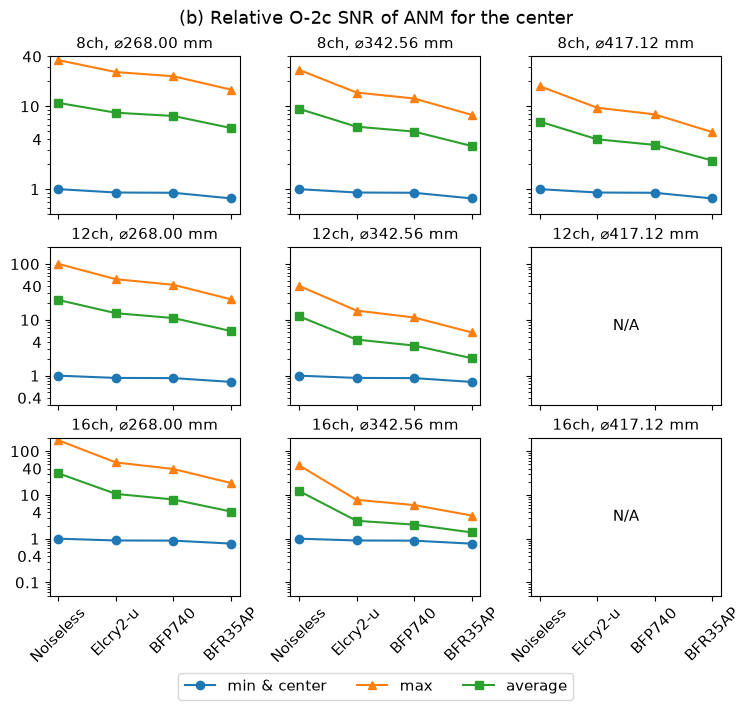

In [21]:
# Generates F4(b)

fig, axs = plt.subplots(3, 3, sharex="all", sharey="row", layout="constrained")
fig.suptitle("(b) Relative O-2c SNR of ANM for the center", fontsize=13)
fig.set_size_inches((7.4, 7))
x_ticks = range(len(transistor_names))
for itm, itn in itertools.product(range(3), range(3)):
    if snr_center_opts[itm, itn, 0] is not None:
        axs[itm, itn].plot(x_ticks, [np.min(snr_center_opts[itm, itn, ito]) for ito in range(len(transistor_names))], marker="o", label="min & center")
        axs[itm, itn].plot(x_ticks, [np.max(snr_center_opts[itm, itn, ito]) for ito in range(len(transistor_names))], marker="^", label="max")
        axs[itm, itn].plot(x_ticks, [np.mean(snr_center_opts[itm, itn, ito]) for ito in range(len(transistor_names))], marker="s", label="average")
        axs[itm, itn].set_yscale("log")
    else:
        axs[itm, itn].text(0.5, 0.5, "N/A", horizontalalignment="center", verticalalignment="center", fontsize=11, transform=axs[itm, itn].transAxes)
    axs[itm, itn].set_title(f"{ch_n[itm]:d}ch, ⌀{sizes[itn] * 2:.2f} mm", fontsize=11) # $\\sigma$={np.std(snr_ratio_maps[itm, itn, ito]):.1%}
    axs[itm, itn].set_xticks(x_ticks, transistor_names, rotation=45, fontsize=11)
    axs[itm, itn].tick_params(axis="both", which="major", labelsize=11)
    axs[itm, itn].tick_params(axis="both", which="minor", labelsize=11)

def format(x: np.number, _) -> str:
    first_significant_digit = np.int_(np.floor(x / 10 ** np.floor(np.log10(x))))
    if first_significant_digit == 1 or first_significant_digit == 4:
        if x < 1:
            return f"{x:.1g}"
        else:
            return f"{int(np.floor(x)):d}"
    else:
        return ""

axs[0, 0].set_ylim((0.5, 40))
axs[1, 0].set_ylim((0.3, 200))
axs[2, 0].set_ylim((0.05, 200))
for itm, itn in itertools.product(range(3), range(3)):
    axs[itm, itn].yaxis.set_major_formatter(ticker.FuncFormatter(format))
    axs[itm, itn].yaxis.set_minor_formatter(ticker.FuncFormatter(format))

handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="outside lower center", ncols=3, fontsize=11)
plt.savefig(save_picture_folder_name+f"\\F4b-{m_mark}.png", dpi=300)

In [22]:
# min_SNR_noiseless = snr_mappers[0, 0, 0]._ref_SNR_map.min()
# Preamp decoupling, anchor value = noiseless amplifier, center pixel
ch_select = 2  # 16 ch
size_select = 0  # size1
center_location_all, _ = field.SNRMapper.find_nearest_point(array_pos_roi0, np.array([0, 0, 115]))
print(f"{center_location_all=:d}")
snr_center_opts_specific = snr_center_opts[ch_select, size_select, ...]
snr_center_noiseless_value = np.float_(0)
for ito in range(len(transistor_names)):
    if z_matrix_generators[ch_select, size_select, ito]._last_signal_vectors_admissible_mask is not None:
        point_coordinates_admissible = array_pos_roi0[z_matrix_generators[ch_select, size_select, ito]._last_signal_vectors_admissible_mask]
        center_location_admissible, _ = field.SNRMapper.find_nearest_point(point_coordinates_admissible, np.array([0, 0, 115]))
        print(f"{center_location_admissible=:d}")
        if ito == 0:
            current_center_location, snr_center_noiseless_value = snr_mappers[ch_select, size_select, ito].SNR_ref_value(
                np.array([0, 0, 115]),
                field.SNRMapper.RefSelect.FIRST_REFERENCE
            )
            print(f"{current_center_location=:d}")
        current_snr_center_opt_normalized = snr_mappers[ch_select, size_select, ito]._SNR_map_bundle / snr_center_noiseless_value
        snr_center_opts_specific[ito] = current_snr_center_opt_normalized
        print(f"{ch_n[ch_select]:d}ch, size{size_select+1:d}, {transistor_names[ito]}: min={current_snr_center_opt_normalized.min():.5%}, max={current_snr_center_opt_normalized.max():.5%}, "
            f"center={current_snr_center_opt_normalized[center_location_all]:.5%}, mean={np.mean(current_snr_center_opt_normalized):.5%}, $\\sigma$={np.std(current_snr_center_opt_normalized):.5f}")

center_location_all=392672
center_location_admissible=3756
current_center_location=392672
16ch, size1, Noiseless: min=99.93343%, max=17750.26353%, center=100.00000%, mean=3115.68763%, $\sigma$=36.53717
center_location_admissible=3756
16ch, size1, Elcry2-u: min=90.98687%, max=5514.70953%, center=91.07081%, mean=1054.45274%, $\sigma$=11.07285
center_location_admissible=3756
16ch, size1, BFP740: min=90.29392%, max=3909.09753%, center=90.39221%, mean=784.93893%, $\sigma$=7.82168
center_location_admissible=3756
16ch, size1, BFR35AP: min=77.18033%, max=1869.11739%, center=77.30045%, mean=417.19455%, $\sigma$=3.70618


[  0.3679   1.     177.503 ]


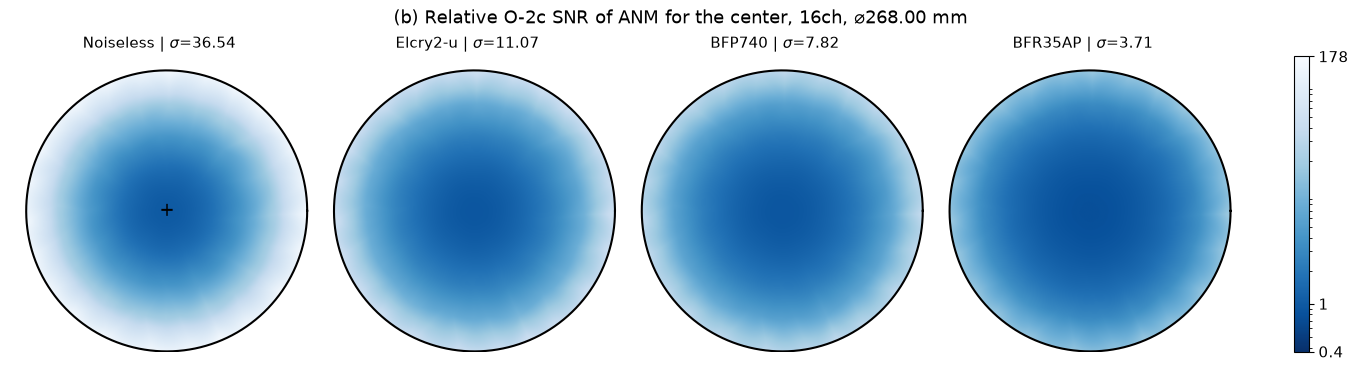

In [23]:
# Generates F5(b)

fig, axs = plt.subplots(1, len(transistor_names), sharey="row", layout="constrained")
fig.set_size_inches((13.5, 3.6))
snr_center_opt_plots = np.empty(len(transistor_names), dtype=np.object_)
mappable_objects = np.empty(len(transistor_names), dtype=np.object_)
fig.suptitle(f"(b) Relative O-2c SNR of ANM for the center, {ch_n[ch_select]}ch, ⌀{sizes[size_select] * 2:.2f} mm", fontsize=13)
circle_phi = np.linspace(0, 2 * np.pi, 5001, False)
circle_x = admissible_region_plots[0, 0].shape[0] * (np.cos(circle_phi) + 1) / 2 - 1
circle_y = admissible_region_plots[0, 0].shape[0] * (np.sin(circle_phi) + 1) / 2 - 1
# ctf_levels = np.geomspace(0.75, 180, num=10, endpoint=True)  # Suggest num=10 or num=13
ctf_levels=np.array([0.3679, 1.0, 177.503])
for ito in range(len(transistor_names)):
    snr_center_opt_plots[ito] = snr_mappers[ch_select, size_select, ito].put_map_on_regular_grid(\
        snr_center_opts_specific[ito], \
        point_admissibility_mask=None, \
        anchor_value=1 \
        )[..., 0]
    mappable_objects[ito] = axs[ito].imshow(snr_center_opt_plots[ito], cmap="Blues_r", norm=colors.LogNorm(0.3679, 177.503)) # levels=ctf_levels, 
    axs[ito].plot(circle_x, circle_y, color="black")
    axs[ito].axis("equal")
    axs[ito].set_axis_off()
    axs[ito].set_title(f"{transistor_names[ito]} | $\\sigma$={np.std(snr_center_opts[ch_select, size_select, ito]):.2f}", fontsize=11) # 

axs[0].text(500.5, 500.5, "+", horizontalalignment="center", verticalalignment="center", fontsize=13)
cbar = fig.colorbar(mappable_objects[0], ax=axs, ticks=ctf_levels, format=ticker.FuncFormatter(colorbar_formatter))
cbar.ax.tick_params(labelsize=11)
print(ctf_levels)
plt.savefig(save_picture_folder_name+f"\\F5b-{m_mark}.png", dpi=300)

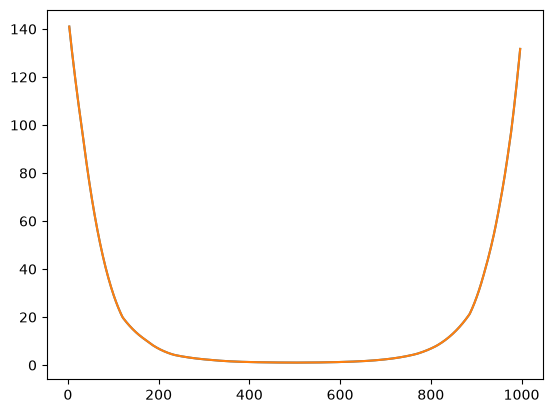

In [24]:
plt.plot(snr_center_opt_plots[0][550,...])
plt.plot(snr_prdcpl_plots[0][550,...])